<a href="https://colab.research.google.com/github/VeronikaShe/ML-study_HW_2/blob/main/HW_2_ROC_PC_SHEMYAKINA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Пункт 1

- Загружаем данные.

- Удаляем все пропущенные значения, преобразуем категориальные переменные.


In [2]:
import numpy as np
import pandas as pd # Для работы с данными
import scipy.stats # При работе со статистикой
import matplotlib.pyplot as plt  # Библиотека для визуализации результатов
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [3]:
# датасет
data = pd.read_csv('https://raw.githubusercontent.com/VeronikaShe/ML-study_HW_2/refs/heads/main/athletes.csv')
data.head()

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
0,736041664,A Jesus Garcia,ESP,male,10/17/69,1.72,64.0,athletics,0,0,0
1,532037425,A Lam Shin,KOR,female,9/23/86,1.68,56.0,fencing,0,0,0
2,435962603,Aaron Brown,CAN,male,5/27/92,1.98,79.0,athletics,0,0,1
3,521041435,Aaron Cook,MDA,male,1/2/91,1.83,80.0,taekwondo,0,0,0
4,33922579,Aaron Gate,NZL,male,11/26/90,1.81,71.0,cycling,0,0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 991.7+ KB


In [5]:
le = LabelEncoder()
le.fit(data['sex'])
y = le.transform(data['sex'])

le.fit(data['nationality'])
nationality = le.transform(data['nationality'])

le.fit(data['sport'])
sport = le.transform(data['sport'])

data = pd.DataFrame({'Hight': data.height,	'Weight':data.weight, 'Gold':	data.gold,	'Silver':data.silver,	'Bronze': data.bronze, 'Nationality':nationality, 'Sport':sport, 'Sex':y })

In [6]:
data.describe()

,Hight,Weight,Gold,Silver,Bronze,Nationality,Sport,Sex
count,11208.000000,10879.000000,11538.000000,11538.000000,11538.000000,11538.000000,11538.000000,11538.000000
mean,1.766282,72.068205,0.057722,0.056769,0.061016,94.864621,10.041082,0.548882
std,0.112719,16.177334,0.255910,0.239147,0.243320,60.067109,8.488756,0.497626
min,1.210000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.690000,60.000000,0.000000,0.000000,0.000000,47.000000,2.000000,0.000000
50%,1.760000,70.000000,0.000000,0.000000,0.000000,85.000000,9.000000,1.000000
75%,1.840000,81.000000,0.000000,0.000000,0.000000,151.000000,17.000000,1.000000
max,2.210000,170.000000,5.000000,2.000000,2.000000,206.000000,27.000000,1.000000


In [7]:
data.replace('?', np.nan , inplace=True)

In [8]:
data.isna().sum()

,0
Hight,330
Weight,659
Gold,0
Silver,0
Bronze,0
Nationality,0
Sport,0
Sex,0


In [9]:
# удаляем ячейки с отсутствием данных
data = data[~(data['Hight'].isna())]
data = data[~(data['Weight'].isna())]

In [10]:
data.isna().sum()

,0
Hight,0
Weight,0
Gold,0
Silver,0
Bronze,0
Nationality,0
Sport,0
Sex,0


In [11]:
data.describe()

,Hight,Weight,Gold,Silver,Bronze,Nationality,Sport,Sex
count,10858.000000,10858.000000,10858.000000,10858.000000,10858.000000,10858.000000,10858.000000,10858.000000
mean,1.766942,72.070915,0.059772,0.058482,0.058574,94.279517,10.306042,0.539878
std,0.113111,16.162358,0.260756,0.242387,0.239113,59.947812,8.581078,0.498430
min,1.210000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.690000,60.000000,0.000000,0.000000,0.000000,44.000000,2.000000,0.000000
50%,1.760000,70.000000,0.000000,0.000000,0.000000,83.000000,9.000000,1.000000
75%,1.840000,81.000000,0.000000,0.000000,0.000000,151.000000,17.000000,1.000000
max,2.210000,170.000000,5.000000,2.000000,2.000000,206.000000,27.000000,1.000000


In [12]:
y = pd.Series(data = np.ravel(data[['Sex']]))
X = data.drop(columns=['Sex'])

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
from sklearn.model_selection import train_test_split

model = LogisticRegression(max_iter=500)

## Пункт 2
Обучение


 Поделим данные на обучающую выборку и тестовую. Указываем в test_size долю датасета, которая пойдет на тестовую выбору

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test.index

Index([   36,  7675,  9226,  6362,  7489,  6263,   742,  9503,  7130,  8835,
       ...
       11205,  1642,  6277,  6542,  9079,  9434,  3802,  9048,   647,  3002],
      dtype='int64', length=2172)

In [16]:
# обучаем на части датасета (train)

model.fit(X_train, y_train)


LogisticRegression(max_iter=500)

In [17]:
predictions0 = model.predict(X_test)

In [18]:
predictions = model.predict_proba(X_test)

<p>Получаем наш скор (точность предсказания) на обучающей и тестовой выборках.</p>

In [19]:
model.score(X_train, y_train)

0.7782638728989179

In [20]:
model.score(X_test, y_test)

0.7794659300184162

Считаем accuracy последней модели

In [21]:
from sklearn.metrics import recall_score, precision_score, accuracy_score


In [22]:
pred = model.predict(X_test)

In [23]:
recall_score(y_test, pred), precision_score(y_test, pred)

(0.7996632996632996, 0.797649034424853)

## Пункт 3.

Строим ROC-кривую


In [42]:
# посчитаем ROC-кривую (Receiver Operating Characteristic)
from sklearn.metrics import roc_curve

In [58]:
# получаем значения false и true positive rate для различных значений порога
fpr, tpr, thres = roc_curve(y_test, predictions[:, 1])

In [44]:
import matplotlib.pyplot as plt
import numpy as np

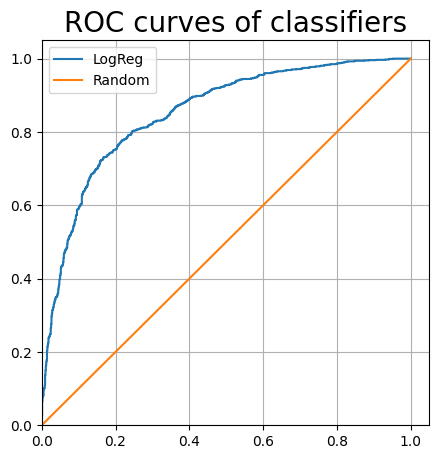

In [45]:
plt.figure(figsize=(5,5))
plt.title('ROC curves of classifiers', fontsize=20)
plt.plot(fpr, tpr, label='LogReg')
plt.plot(np.linspace(0,1,10), np.linspace(0,1,10), label='Random')
plt.xlim(0,1.05)
plt.ylim(0,1.05)
plt.grid()
plt.legend()
plt.show()

## Пункт 4

Посчитаем ROC-AUC метрику

In [46]:
from sklearn.metrics import roc_auc_score

In [72]:
roc_auc_score(y_test, predictions[:, 1]).round(2)

np.float64(0.85)

## Пункт 5

Подсчитаем метрикы TPR, FPR «вручную»

In [70]:

fpr_manual_list = []
tpr_manual_list = []
precision_manual_list = []
predictions = model.predict_proba(X_test)
for iter in range(0, 100, 1):
    tp = 0 # True positive
    fp = 0 # False positive
    fn = 0 # False negative
    tn = 0 # True negative
    for predicted_prob, actual in zip(predictions[:, 1], y_test):
        if predicted_prob >= iter/100:
            predicted = 1
        else:
            predicted = 0

        if predicted == 1:
            if actual == 1:
                tp += 1
            else:
                fp += 1
        else:
            if actual == 1:
                fn += 1
            else:
                tn += 1
    fpr_manual = fp / (fp + tn)
    tpr_manual = tp / (tp + fn)
    precision_manual = tp / (tp + fp)
    fpr_manual_list.append (fpr_manual)
    tpr_manual_list.append (tpr_manual)
    precision_manual_list.append (precision_manual)

In [49]:
tp, fp, fn, tn

(950, 241, 238, 743)

## Пункт 8

Посчитаем ROC-AUC метрики по измерениям полученным вручную


In [50]:
# какая accuracy получилась? Посчитаем для порога 0.5
(tp + tn) / (tp + fp + fn + tn)

0.7794659300184162

In [51]:
precision = tp / (tp + fp)
precision

0.797649034424853

In [52]:
recall = tp / (tp + fn)
recall

0.7996632996632996

In [53]:
fpr_manual = fp / (fp + tn)
fpr_manual

0.24491869918699186

In [54]:
tpr_manual = tp / (tp + fn)
tpr_manual

0.7996632996632996

## Пункт 6

Построим на одном графике обе ROC-кривые

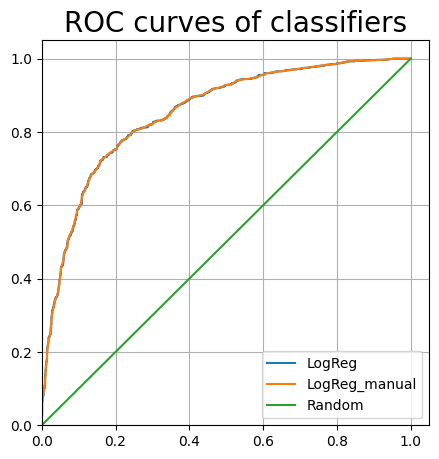

In [68]:
plt.figure(figsize=(5,5))
plt.title('ROC curves of classifiers', fontsize=20)
plt.plot(fpr, tpr, label='LogReg')
plt.plot(fpr_manual_list, tpr_manual_list, label='LogReg_manual')
plt.plot(np.linspace(0,1,10), np.linspace(0,1,10), label='Random')
plt.xlim(0,1.05)
plt.ylim(0,1.05)
plt.grid()
plt.legend()
plt.show()

ROC-кривые совпали как построеные вручную, так и при помощи библиотеки

## Пункт 7

Построим график Precision-Recall, используя метрики, посчитанные в п. 5.

(0.0, 1.0)

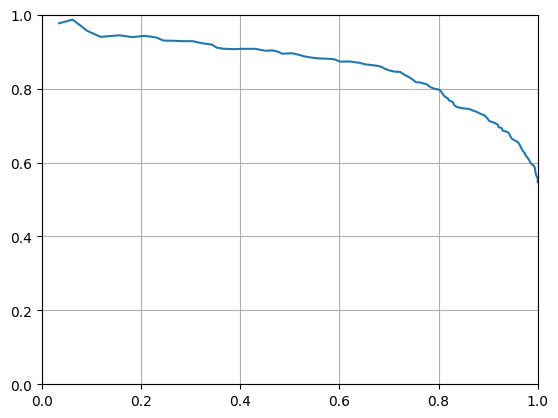

In [71]:
plt.plot(tpr_manual_list, precision_manual_list)
plt.grid()
plt.xlim(0, 1)
plt.ylim(0, 1)

## Пункт 9.

Вывод

a) Чем больше площад под ROC - кривой и под precision-recall, тем более точна модель. ROC более показательна для сбалансированных датасетов. ROC в нашем случае более показательна. ROC > 0,8 что говорит о том, что модель работает превосходно.

b) Если ROC - кривая проходит ниже диагонали, то необходимо инвертировать критерий.
